## **Regressão Logística Binária**

Dado um conjunto de observações

$$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N
\quad \text{onde}
\quad \mathbf{x}_i \in \mathbb{R}^{D} \text{ e } y_i \in y_i \in \{0, 1\}
$$

definimos o vetor aumentado $\tilde{\mathbf{x}}_i$ como:

$$
\tilde{\mathbf{x}}_i = \begin{bmatrix} 1 \\ \mathbf{x}_i \end{bmatrix}
$$

construímos então $\mathbf{X}$, **a matriz com o intercepto**, $\mathbf{y}$ e $\mathbf{w}$:

$$
\mathbf{X} =
\begin{bmatrix}
\tilde{\mathbf{x}}_1^{\top} \\
\tilde{\mathbf{x}}_2^{\top} \\
\vdots \\
\tilde{\mathbf{x}}_N^{\top}
\end{bmatrix}
=
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1D} \\
1 & x_{21} & x_{22} & \cdots & x_{2D} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{N1} & x_{N2} & \cdots & x_{ND}
\end{bmatrix},
\qquad
\mathbf{y} =
\begin{bmatrix}
y_1 \\ y_2 \\ \vdots \\ y_N
\end{bmatrix},
\qquad
\mathbf{w} =
\begin{bmatrix}
w_0 \\ w_1 \\ \vdots \\ w_D
\end{bmatrix}.
$$

Sabemos que $y_{i} \sim \text{Bernoulli}(p_{i})$ onde $p_i$ é dada por:

$$
p_i = P(y_i = 1 \mid \mathbf{x}_i;\, \mathbf{w}) = \sigma\left(\tilde{\mathbf{x}}_i^{\top} \mathbf{w}\right)$$

onde

$$
 \sigma\left(\tilde{\mathbf{x}}_i^{\top} \mathbf{w}\right) = \frac{1}{1 + e^{-(\tilde{\mathbf{x}}_i^{\top}\mathbf{w})}}
$$

Assumindo a independência condicional de $y_i$ dado $\mathbf{X}$, vamos definir a função de verossimilhança como:

$$
\mathcal{L}(\mathbf{w}) = \prod_{i=1}^{N} p_i^{y_i}(1 - p_i)^{1 - y_i}
$$

Substituindo $p_i$ por $ \sigma\left(\tilde{\mathbf{x}}_i^{\top} \mathbf{w}\right)$ temos que:

$$
\mathcal{L}(\mathbf{w}) = \prod_{i=1}^{N} [\sigma\left(\tilde{\mathbf{x}}_i^{\top} \mathbf{w}\right)]^{y_i}[1 - \sigma\left(\tilde{\mathbf{x}}_i^{\top} \mathbf{w}\right)]^{1 - y_i}
$$

Fazendo $\ell(\mathbf{w}) = \log \mathcal{L}(\mathbf{w})$, segue que

$$
\ell(\mathbf{w}) = \sum_{i=1}^{N} \left[ y_i \log \sigma\left(\tilde{\mathbf{x}}_i^{\top}\mathbf{w}\right) + (1 - y_i)\log\left(1 - \sigma\left(\tilde{\mathbf{x}}_i^{\top}\mathbf{w}\right)\right) \right]
$$

Essa é a chamada **função log-verossimilhança**.

Dada a função $\ell(\mathbf{w})$, podemos seguir com duas abordagens:

*   Método de Newton
*   Método do Gradiente Descendente

### **Método de Newton**

Nessa técnica, o objetivo é **maximizar** a função **log-verossimilhança**. Nesse método, a iteração é dada por:


$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \mathbf{H}^{-1}\left(\mathbf{w}^{(t)}\right)\, \nabla \ell\left(\mathbf{w}^{(t)}\right)$$

onde $\nabla \ell(\mathbf{w})$ é o gradiente e $\mathbf{H}$ é a matriz Hessiana.

Calculando $\nabla \ell(\mathbf{w})$ temos:

$$
\nabla \ell(\mathbf{w}) = \mathbf{X}^{\top}(\mathbf{y} - \mathbf{p})
$$

Sendo a matriz Hessiana dada por:

$$
\mathbf{H} = -\mathbf{X}^{\top}\mathbf{W}\mathbf{X}
$$

onde:

$$
\mathbf{W} = \operatorname{diag}(p_i(1 - p_i))
$$

Substituindo na fórmula de iteração, temos que:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} + \left(\mathbf{X}^{\top}\mathbf{W}\mathbf{X}\right)^{-1} \mathbf{X}^{\top}(\mathbf{y} - \mathbf{p})
$$


### **Método do Gradiente Descendente**

Em ML geralmente **minimizamos** a função chamada de **Entropia Cruzada**, também conhecida por log-verossimilhança negativa:


$$
J(\mathbf{w}) = -\dfrac{1}{N}\ell(\mathbf{w})
$$

onde $\ell(\mathbf{w})$ é a função de log-verossimilhança.

Substituindo, temos que:

$$
J(\mathbf{w}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log \sigma\!\left(\tilde{\mathbf{x}}_i^{\top}\mathbf{w}\right) + (1 - y_i)\log\left(1 - \sigma\left(\tilde{\mathbf{x}}_i^{\top}\mathbf{w}\right)\right) \right]
$$

Como dito, queremos no método do GD minimizar $J(\mathbf{w})$. Para isso, usa-se a seguinte iteração:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \, \nabla J\left(\mathbf{w}^{(t)}\right)
$$

Dado que $\nabla J(\mathbf{w})$ é dado por:

$$
\nabla J(\mathbf{w}) = \frac{1}{N}\, \mathbf{X}^{\top}(\mathbf{p} - \mathbf{y})$$

temos que:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \frac{\eta}{N}\, \mathbf{X}^{\top}\left(\mathbf{p}^{(t)} - \mathbf{y}\right)
$$

## **Aplicação Básica de Regressão Logística usando o Método de Newton**

Vamos utilizar a **Regressão Logística** para uma tarefa de **classificação** em um dataset sintético.

### **Pré-processamento dos dados**

#### **Dataset**

In [497]:
from sklearn.datasets import make_blobs
from random import randint
import numpy as np

c_x, c_y = randint(1, 3), randint(1, 3)

X, y = make_blobs(
    n_samples=200,
    centers=[[-c_x, c_y], [c_y, -c_x]],
    cluster_std=2.5,
    random_state=42
)

#### **Visualização dos dados**

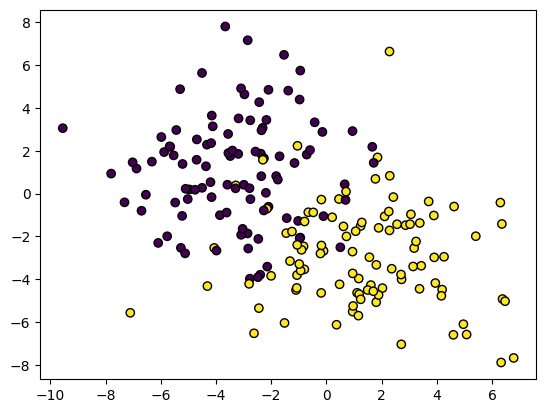

In [498]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
plt.show()

#### **Divisão do dataset em conjuntos de treino e validação**

In [499]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (160, 2)
Teste: (40, 2)


#### **Padronização dos dados (z-score)**

In [500]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### **Adicionando intercepto na matriz $\mathbf{X}$**

In [501]:
def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

X_train = add_bias(X_train)
X_test = add_bias(X_test)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (160, 3)
Teste: (40, 3)


### **Implementando a Regressão Logística Binária (Método de 2ª ordem)**

#### **Funções auxiliares**

In [502]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gradient(X, y, w):
    p = sigmoid(X @ w)
    return X.T @ (y - p)

def hessian(X, w):
    p = sigmoid(X @ w)
    W = np.diag(p * (1 - p))
    return - X.T @ W @ X

def log_likelihood(X, y, w):
    p = sigmoid(X @ w)
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


In [503]:
def logistic_regression_newton(X, y, max_iter=100, tol=1e-6):
    n, d = X.shape
    w = np.zeros(d)
    losses = []

    for i in range(max_iter):

        loss = log_likelihood(X, y, w)
        losses.append(loss)
        print(f"Iter {i+1:3d} | Loss: {loss:.6f}")

        grad = gradient(X, y, w)
        H = hessian(X, w)

        delta = np.linalg.solve(H, grad)
        w_new = w - delta

        if np.linalg.norm(w_new - w) < tol:
            w = w_new
            break

        w = w_new

    return w, losses

### **Treinamento e Validação**

#### **Treinamento**

In [504]:
w, losses = logistic_regression_newton(X_train, y_train)

Iter   1 | Loss: -110.903549
Iter   2 | Loss: -55.260956
Iter   3 | Loss: -44.753918
Iter   4 | Loss: -42.190797
Iter   5 | Loss: -41.906581
Iter   6 | Loss: -41.901249
Iter   7 | Loss: -41.901246


#### **Valor de $\mathbf{w}$ ótimo**

In [505]:
for i, b in enumerate(w.flatten()):
    print(f"w{i}: {b:.4f}")

w0: 0.0088
w1: 2.5731
w2: -1.9149


#### **Curva de Aprendizado**

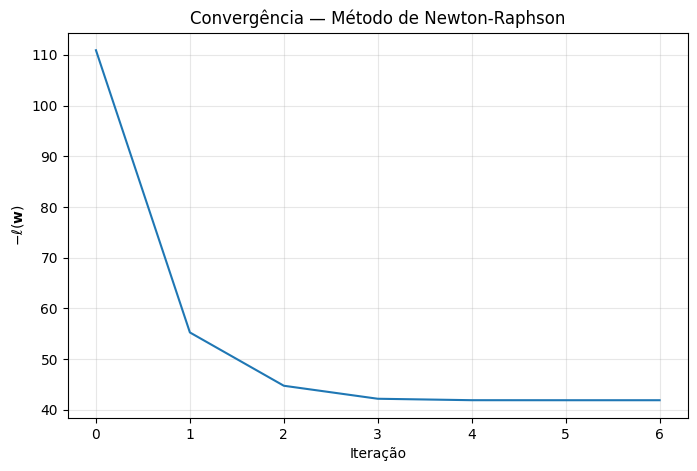

In [506]:
plt.figure(figsize=(8, 5))
plt.plot(-np.array(losses))
plt.xlabel("Iteração")
plt.ylabel(r"$-\ell(\mathbf{w})$")
plt.title(r"Convergência — Método de Newton-Raphson")
plt.grid(True, alpha=0.3)
plt.show()

#### **Validação**

In [507]:
def predict(X, w):
    probs = sigmoid(X @ w)
    return (probs >= 0.5).astype(int), probs.round(4)

In [508]:
y_pred, prob = predict(X_test, w)

#### **Matriz de Confusão**

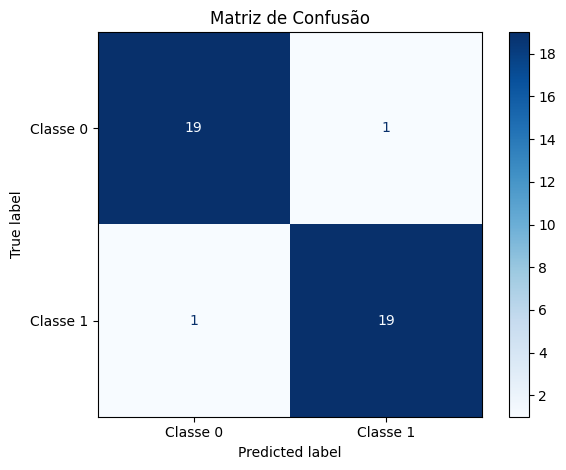

In [509]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Classe 0", "Classe 1"])

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

#### **Métricas**

In [510]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Classe 0", "Classe 1"]))

              precision    recall  f1-score   support

    Classe 0       0.95      0.95      0.95        20
    Classe 1       0.95      0.95      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40

